In [1]:
import requests
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
from urllib.parse import urljoin
import re
import tarfile
import io
import networkx as nx
from typing import Any, Dict, List, Tuple, Optional
from collections import deque
from random import randint
from IPython.display import display, clear_output
import os


PRE_URL = 'https://objectstorage.sa-santiago-1.oraclecloud.com/p/ClGAiyiKUpSQf4ZwdXXmQLaurz9fDIrnQ_iP1d4LTXv57aZgCk2D1vi0NaEOfWs2/n/axosppplfddw/b/bucket-scl-prod-monitoreosscc-datalake-001/o/'
#FILE_NODOS = 'Report_paths_sitios_M10_W42_254_v2.0.xlsx'
FILE_TOPO = 'topo_edges_nodes_ipran_v20.xlsx'
LOCAL_DIR = 'FILES'

COMUNA = 'Antofagasta'

YEAR = 2025
WEEK = [45,46]

# NODOS

In [2]:
NODES_SELECTED = pd.read_excel(FILE_TOPO, sheet_name='NODES')
NODES_SELECTED = NODES_SELECTED[ NODES_SELECTED.Comuna == COMUNA ]
NODES_SELECTED.Latitude = pd.to_numeric(NODES_SELECTED.Latitude)
NODES_SELECTED.Longitude = pd.to_numeric(NODES_SELECTED.Longitude)
NODES_SELECTED = NODES_SELECTED[NODES_SELECTED.Site.str.match(r'\d\d[isp_]\d+$')]

print(f'Numero de Nodos: {len(NODES_SELECTED)}')
NODES_SELECTED.set_index('Site', inplace=True)
NODES_SELECTED.sample(frac=0.1)

Numero de Nodos: 47


,SiteName,Latitude,Longitude,Comuna,Region,Provincia,cod_comuna
Site,,,,,,,
02_020,Mantos Blancos,-23.489997,-70.115056,Antofagasta,Región de Antofagasta,Antofagasta,2101
02_422,ANF Hipodromo,-23.583999,-70.389137,Antofagasta,Región de Antofagasta,Antofagasta,2101
02_489,Hub Antofagasta,-23.629576,-70.386228,Antofagasta,Región de Antofagasta,Antofagasta,2101
02_413,Aguas ANF Balmaceda,-23.606207,-70.372447,Antofagasta,Región de Antofagasta,Antofagasta,2101
02_407,Aguas ANF El Ancla,-23.636056,-70.382692,Antofagasta,Región de Antofagasta,Antofagasta,2101


# ENLACES

In [3]:
EDGES = pd.read_excel(FILE_TOPO)
EDGES.A = EDGES.A.str.strip().str.lower()
EDGES.B = EDGES.B.str.strip().str.lower()
EDGES.PtaA = EDGES.PtaA.str.strip().str.lower().str.replace('\'', '')

UNIQUE_IDS = np.unique(EDGES.A.unique().tolist() + EDGES.B.unique().tolist() + NODES_SELECTED.index.unique().tolist())
UNIQUE_IDS = { str(x):str(i).zfill(5) for i,x in enumerate(UNIQUE_IDS)}

EDGES['A_id'] = EDGES.A.map(UNIQUE_IDS)
EDGES['B_id'] = EDGES.B.map(UNIQUE_IDS)
EDGES['Instance_Id'] = EDGES.apply(lambda x: f"{x.A_id}{x.B_id}" if int(x.A_id) >= int(x.B_id) else  f"{x.B_id}{x.A_id}", axis=1)

PORT_IDS = np.unique(EDGES.PtaA.tolist())
PORT_IDS = {str(x):str(i).zfill(5) for i,x in enumerate(PORT_IDS)}

EDGES['PtaA_Id'] = EDGES.PtaA.map(PORT_IDS)
EDGES['Port_Id'] = EDGES.A_id + EDGES.PtaA_Id

PORT_ID_TO_INSTACE_ID = {k:v for k,v in EDGES.groupby('Port_Id')['Instance_Id'].max().items()}


#REMOVING REDUNDANT EDGES
EDGES['most_freq'] = EDGES.groupby('Instance_Id')['A'].transform(lambda x: x.mode().iloc[0])
EDGES = EDGES[EDGES.A == EDGES.most_freq]

EDGES = EDGES.drop(['A_id','B_id','PtaA_Id','IDX','most_freq'], axis=1)

print(f'Inventario de Enlaces: {len(EDGES)}')
EDGES.set_index('Instance_Id', inplace=True)

EDGES.sample(5)

Inventario de Enlaces: 10163


,A,PtaA,Descripcion,B,Type,Medio,Capacidad,Port_Id
Instance_Id,,,,,,,,
0760707125,910c_puente_la_union_csr_10615,gigabitethernet0/2/0,to_910c_vivero_union_rios_csr_14106_0/2/1,910c_vivero_union_rios_csr_14106,CORE,FO,10000.0,0712500128
0470502722,6120_fisa_csr_r8_13522,xxvgei-1/1/0/11,'to_enodeb_13_522_huawei',13_522,SITIO,NaN,10000.0,0470500395
0844708167,sara_bellavista_csr_r4_ml5001,1/1/2,to_vicente_valdes_ml4014_1/1/1,sarm_vic_valdes_csr_r4_ml4014,CORE,FO,1000.0,0816700004
0847100178,sarwx_paramos_atacama_csr_02510,1/1/3,'to_enodeb_02_510_huawei',02_510,SITIO,Starlink,1000.0,0847100005
0581503502,6120_terminal_de_buses_25101,xgei-1/1/0/2,'to_nodeb_terminal_de_buses_25l101',25_101,SITIO,NaN,1000.0,0581500357


## CREATING GRAPH

In [4]:
def path_to_regex(G: nx.Graph, source: Any, pattern: str, *, name_attr: str = "name", max_hops: Optional[int] = None, return_edges: bool = True, debug: bool = False) -> Dict[str, Any]:

    if source not in G:
        raise ValueError(f"Source node {source!r} not in graph")

    regex = re.compile(pattern)

    def _matches(node: Any) -> bool:

        if regex.search(str(node)):
            return True

        data = G.nodes[node]
        if name_attr in data and data[name_attr] is not None:
            return bool(regex.search(str(data[name_attr])))
        return False


    if _matches(source):
        nodes_path = [source]
        result = {
            "found": True,
            "target": source,
            "nodes_path": nodes_path,
            "hops": 0,
            "edges_path": [],
            "debug_trace": [{"node": source, "depth": 0}] if debug else None,
        }
        return result


    q = deque([(source, 0)])
    parent: Dict[Any, Any] = {source: None}
    depth: Dict[Any, int] = {source: 0}
    dbg: List[Dict[str, Any]] = [{"node": source, "depth": 0}] if debug else None

    def _neighbors(u):
        if G.is_directed():
            return G.successors(u)
        return G.neighbors(u)

    target: Optional[Any] = None
    while q:
        u, d = q.popleft()
        if max_hops is not None and d >= max_hops:
            continue
            
        for v in _neighbors(u):
            if v in parent:
                continue
                
            parent[v] = u
            depth[v] = d + 1
            if debug:
                dbg.append({"node": v, "depth": d + 1})
            if _matches(v):
                target = v
                q.clear()
                break
            q.append((v, d + 1))

    def _reconstruct_path(end_node: Any) -> List[Any]:
        path = []
        cur = end_node
        while cur is not None:
            path.append(cur)
            cur = parent.get(cur)
        path.reverse()
        return path

    if target is not None:
        nodes_path = _reconstruct_path(target)
        found = True
    else:
        found = False
        if len(depth) == 1:
            nodes_path = [source]
        else:
            if debug and dbg:
                max_d = max(entry["depth"] for entry in dbg)
                far_node = next(entry["node"] for entry in dbg if entry["depth"] == max_d)
            else:
                max_d = max(depth.values())
                deep_nodes = [n for n, dep in depth.items() if dep == max_d]
                far_node = sorted(map(str, deep_nodes))[0]

                for n in deep_nodes:
                    if str(n) == far_node:
                        far_node = n
                        break
                        
            nodes_path = _reconstruct_path(far_node)

    edges_path: List[Tuple[Tuple[Any, Any], Dict[str, Any]]] = []
    if return_edges and len(nodes_path) > 1:
        for u, v in zip(nodes_path, nodes_path[1:]):
            data = G.get_edge_data(u, v)
            if G.is_multigraph():
                key = sorted(data.keys())[0]
                attrs = dict(data[key]) if data is not None else {}
            else:
                attrs = dict(data) if data is not None else {}
            edges_path.append(((u, v), attrs))

    return {
        "found": found,
        "target": nodes_path[-1],
        "nodes_path": nodes_path,
        "edges_path": edges_path,
        "hops": len(nodes_path) - 1,
        "debug_trace": dbg if debug else None,
    }


    if not copy_graph:
        return graph.reverse(copy=False)

    if isinstance(graph, nx.MultiDiGraph):
        new = nx.MultiDiGraph()
        new.graph.update(deepcopy(graph.graph))
        new.add_nodes_from((n, deepcopy(data)) for n, data in graph.nodes(data=True))
        for u, v, k, data in graph.edges(keys=True, data=True):
            new.add_edge(v, u, key=k, **deepcopy(data))
    else:
        new = graph.__class__()
        new.graph.update(deepcopy(graph.graph))
        new.add_nodes_from((n, deepcopy(data)) for n, data in graph.nodes(data=True))
        for u, v, data in graph.edges(data=True):
            new.add_edge(v, u, **deepcopy(data))
            
    return new

def draw_network_with_flows(G, edge_flows, sinks, sources):
    """
    Draws the network graph with edge labels showing the mean flow.
    """
    # Use a fixed layout for reproducibility
    #pos = nx.spring_layout(G, seed=52)

    # Use Kamada-Kawai layout to approximate fixed/equal edge lengths
    # This layout attempts to position nodes so that geometric distance matches graph distance
    try:
        pos = nx.kamada_kawai_layout(G)
    except ImportError:
        # Fallback if scipy is not available (required for kamada_kawai)
        print("Warning: Scipy not found. Using spring_layout as fallback.")
        pos = nx.spring_layout(G, seed=42, k=0.5, iterations=100)

    # Calculate mean flows for labels
    edge_means = {}
    for edge, flow_series in edge_flows.items():
        edge_means[edge] = np.mean(flow_series)

    # Define Node Colors
    node_colors = []
    for node in G.nodes():
        if node in sinks:
            node_colors.append('#ff9999') # Red for Sinks
        elif node in sources:
            node_colors.append('#99ff99') # Green for Sources
        else:
            node_colors.append('#d3d3d3') # Gray for others

    plt.figure(figsize=(10, 6))
    
    # Draw Nodes
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=800, edgecolors='black')
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

    # Draw Edges (Width proportional to mean flow)
    max_flow = max(edge_means.values()) if edge_means else 1.0
    # Base width 1, max width 5
    widths = [1 + 4 * (edge_means.get(e, 0) / max_flow) for e in G.edges()]
    
    nx.draw_networkx_edges(G, pos, width=widths, arrowstyle='-|>', arrowsize=20, edge_color='gray')

    # Draw Edge Labels (Mean Values)
    edge_labels = {e: f"{mean_val:.2f}" for e, mean_val in edge_means.items()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='blue', font_size=9)

    plt.title("Network Topology with Mean Flow per Edge")
    plt.axis('off')
    plt.tight_layout()
    plt.show()


In [5]:
G = nx.DiGraph()
for k,v in EDGES.iterrows():
    if v['Type'] == 'SITIO':
        G.add_edge(v['A'], v['B'], instance_Id=k, port_id=v['Port_Id'], edge_type=v['Type'])
    elif v['Type'] == 'OLT':
        G.add_edge(v['B'], v['A'], instance_Id=k, port_id=v['Port_Id'], edge_type=v['Type'])
    elif v['Type'] == 'STARLINK':
        G.add_edge(v['B'], v['A'], instance_Id=k, port_id=v['Port_Id'], edge_type=v['Type'])
    else:
        G.add_edge(v['A'], v['B'], instance_Id=k, port_id=v['Port_Id'], edge_type=v['Type'])
        G.add_edge(v['B'], v['A'], instance_Id=k, port_id=v['Port_Id'], edge_type=v['Type'])

G_COMUNA = nx.DiGraph()

print(f"Numero de enlaces a nivel nacional: {len(G.to_undirected().edges)}")
print(f"Numero de nodos a nivel nacional: {len(G.to_undirected().nodes)}")
print()


for site in NODES_SELECTED.index:
    try:
        _found = path_to_regex(G.reverse(), source=site, pattern=r'.*_hr[_]?[ab]_', max_hops=10, debug=False)
        G_COMUNA.add_edges_from([(x[0][0],x[0][1], x[1]) for x in  _found['edges_path']])
    except ValueError:
        print(f'Path not found for node: {site}')

nx.set_node_attributes(G_COMUNA, {x: NODES_SELECTED.loc[x].to_dict() for x in NODES_SELECTED.index})
G_COMUNA = G_COMUNA.reverse()

print(f'Numero de enlaces con nodos selecionados {G_COMUNA.number_of_edges()}')
print(f'Numero de nodos con nodos selecionados {G_COMUNA.number_of_nodes()}')

Numero de enlaces a nivel nacional: 9419
Numero de nodos a nivel nacional: 8496

Path not found for node: 02_134
Path not found for node: 02_412
Numero de enlaces con nodos selecionados 94
Numero de nodos con nodos selecionados 96


### FILTER IDS

In [6]:
_selected_instance_ids = [x[2]['instance_Id'] for x in G_COMUNA.edges(data=True)]
PORT_IDS_SELECTED = EDGES.loc[_selected_instance_ids,'Port_Id'].unique().tolist()



## GETTING DATA BW

In [12]:
def get_files_and_dates(url):
    """
    Retrieves file list from JSON API and adds date-based columns (Year, Month, Week, Day).
    """
    try:
        # 1. Fetch and Parse JSON
        response = requests.get(url)
        response.raise_for_status()
        data = response.json()
        
        # 2. Create DataFrame
        df = pd.DataFrame(data.get("objects", []))
        
        # 3. Filter out directories (names ending in '/')
        if not df.empty and 'name' in df.columns:
            df = df[~df['name'].str.endswith('/')].copy()
            
            # 4. Extract simple filename
            df['filename'] = df['name'].apply(lambda x: x.split('/')[-1])
            
            # 5. Extract Date String using Regex (finds 8 consecutive digits)
            # This looks for patterns like '20250509' in the filename
            def extract_date_str(text):
                match = re.search(r'(\d{8})', text)
                return match.group(1) if match else None

            df['date_temp'] = df['filename'].apply(extract_date_str)
            
            # 6. Convert to Datetime Object
            df['date_obj'] = pd.to_datetime(df['date_temp'], format='%Y%m%d', errors='coerce')
            
            # 7. Create New Columns
            df['year'] = df['date_obj'].dt.year
            df['month'] = df['date_obj'].dt.month
            df['week'] = df['date_obj'].dt.isocalendar().week
            df['day'] = df['date_obj'].dt.day
            
            # 8. Cleanup (remove temporary columns)
            df.drop(columns=['date_temp', 'date_obj'], inplace=True)
            
            # (Optional) Drop rows where date could not be found
            df.dropna(subset=['year'], inplace=True)
            
            # Convert float columns to integer (pandas makes them float if NaNs existed)
            cols = ['year', 'month', 'week', 'day']
            df[cols] = df[cols].astype(int)
        df = df.rename(columns={'name': 'remote_path'})

        return df

    except requests.exceptions.RequestException as e:
        print(f"Error fetching URL: {e}")
        return pd.DataFrame()

def download_and_cache(url, download_dir="FILES"):
    """
    Handles the network and disk layer: 
    Ensures the file exists locally and returns the local path.
    """
    os.makedirs(download_dir, exist_ok=True)
    filename = url.split('/')[-1]
    file_path = os.path.join(download_dir, filename)

    if os.path.exists(file_path):
        print(f"File found locally: {file_path}. Skipping download.")
        return file_path

    print(f"Downloading: {url}")
    try:
        response = requests.get(url, stream=True, timeout=30)
        response.raise_for_status()
        
        with open(file_path, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print("Download complete.")
        return file_path
        
    except Exception as e:
        print(f"Download failed for {url}: {e}")
        if os.path.exists(file_path):
            os.remove(file_path)
        return None

def extract_and_concat_csvs(file_path, **kwargs):
    """
    Handles the data layer: 
    Opens a local .tgz file, reads internal CSVs, and merges them.
    """
    if not file_path or not os.path.exists(file_path):
        return pd.DataFrame()

    dfs = []
    try:
        with tarfile.open(file_path, "r:gz") as tar:
            for member in tar.getmembers():
                if member.isfile() and member.name.lower().endswith('.csv'):
                    f = tar.extractfile(member)
                    if f:
                        df = pd.read_csv(f, sep=';', **kwargs)
                        df['source_file'] = member.name
                        dfs.append(df)
        
        if dfs:
            return pd.concat(dfs, ignore_index=True)
        
        print(f"No CSVs found in {file_path}")
        return pd.DataFrame()

    except Exception as e:
        print(f"Error processing archive {file_path}: {e}")
        return pd.DataFrame()

FILES = get_files_and_dates(PRE_URL) 
FILES = FILES.sort_values(by=['year', 'month','day'])
FILES = FILES[FILES.filename.str.contains(".tgz")]
FILES = FILES[FILES.filename.str.contains("reporte_diario_floky_ipran")]
FILES = FILES[FILES.week.isin(WEEK)]
FILES['remote_path'] = FILES['remote_path'].apply(lambda x: PRE_URL + x)
FILES['local_path_tgz'] = FILES['filename'].apply(lambda x: f"{LOCAL_DIR}/{x}")
FILES['local_path_parquet'] = FILES['filename'].apply(lambda x: f"{LOCAL_DIR}/{x.replace('.tgz', '.parquet')}")


print("Extracting files...")
for index, row in FILES.iterrows():
    #_parquet_path = row.local_path.replace(".tgz", ".parquet")

    if not os.path.exists(row.local_path_parquet):
        print(f"File not found locally: {row.local_path}, Downloading...")
        download_and_cache(row.remote_path)
        _extracted_df = extract_and_concat_csvs(row.local_path_tgz)
    
        print(f"Extracted {len(_extracted_df)} rows from {row.local_path} to {row.local_path}")
        print(f"Saving to {row.local_path_parquet}")
        _extracted_df.to_parquet(row.local_path_parquet) 
        
        del _extracted_df
    else:
        print(f"File found locally: {row.local_path_parquet}. Skipping extraction.")



Extracting files...
File found locally: FILES/reporte_diario_floky_ipran_20251103.parquet. Skipping extraction.
File found locally: FILES/reporte_diario_floky_ipran_20251104.parquet. Skipping extraction.
File found locally: FILES/reporte_diario_floky_ipran_20251105.parquet. Skipping extraction.
File found locally: FILES/reporte_diario_floky_ipran_20251106.parquet. Skipping extraction.
File found locally: FILES/reporte_diario_floky_ipran_20251107.parquet. Skipping extraction.
File found locally: FILES/reporte_diario_floky_ipran_20251108.parquet. Skipping extraction.
File found locally: FILES/reporte_diario_floky_ipran_20251109.parquet. Skipping extraction.
File found locally: FILES/reporte_diario_floky_ipran_20251110.parquet. Skipping extraction.
File found locally: FILES/reporte_diario_floky_ipran_20251111.parquet. Skipping extraction.
File found locally: FILES/reporte_diario_floky_ipran_20251112.parquet. Skipping extraction.
File found locally: FILES/reporte_diario_floky_ipran_2025111

In [ ]:
def proc_ipran_file(path:str, filter_list:list=[], unique_ids:dict={}, port_ids:dict={}): 
    

    _data = pd.read_parquet(path)

    
    
    _data.columns = [
        'Equipo',
        'Puerta',
        'IfdevId',
        'Descripcion', 
        'Fecha_Hora', 
        'Tput_in_bps',
        'Tput_out_bps', 
        'Capacidad_Fisica', 
        'Capacidad_Operativa', 
        'Tab',
        'source_file'
    ]
 

    

    _data = _data[pd.notnull(_data.Fecha_Hora)]
    _data = _data[pd.notnull(_data.Equipo)]
    _data.Equipo = _data.Equipo.str.strip().str.lower().str.replace("'", "", regex=False)
    _data.Puerta = _data.Puerta.str.strip().str.lower().str.replace("'", "", regex=False)

    _data = _data[_data.Puerta.str.match(r'.*\/\d+$')]
    _data = _data[~_data.Equipo.str.match(r'.*\.csv')]


    _data['A'] = _data.Equipo.str.strip().str.lower().str.replace("'", "", regex=False)
    _data['PtaA']  = _data.Puerta.str.strip().str.lower().str.replace("'", "", regex=False)

    _data['A_id'] = _data.A.map(unique_ids).copy()
    _data = _data[_data.A_id.notna()]
    _data['PtaA_Id'] = _data.PtaA.map(port_ids).copy()
    _data['Port_Id'] = _data.A_id + _data.PtaA_Id
    _data = _data[_data.Port_Id.notna()]

    _data = _data[_data.Port_Id.isin(filter_list)]
    
    _data = _data[ _data.Fecha_Hora.str.match(r'\d\d\d\d-\d\d-\d\d \d\d:\d\d:\d\d')]
    _data.Fecha_Hora = pd.to_datetime(_data.Fecha_Hora, format='%Y-%m-%d %H:%M:%S')

    _data['in'] =  pd.to_numeric(_data.Tput_in_bps, errors='coerce' ) / 1000000
    _data['out'] = pd.to_numeric(_data.Tput_out_bps, errors='coerce' ) / 1000000
    _data['capacity'] = pd.to_numeric(_data[['Capacidad_Fisica','Capacidad_Operativa']].min(axis=1), errors='coerce' ).fillna(1001)

    _data = _data[['A', 'PtaA','Fecha_Hora','in', 'out','capacity']]

    _data.set_index(['Port_Id'], inplace=True)

    return _data

#proc_ipran_file("FILES/reporte_diario_floky_ipran_20251107.parquet", filter_list=PORT_IDS_SELECTED, unique_ids=UNIQUE_IDS, port_ids=PORT_IDS)

In [15]:

if os.path.exists('DATA_RAW.parquet'):
    print("File found locally: DATA_RAW.parquet. Skipping processing.")
    DATA_RAW = pd.read_parquet('DATA_RAW.parquet')
else:
    _files_processed = []
    for path in FILES.local_path_parquet:
        print(f"Reading {path}")
        _files_processed.append(proc_ipran_file(path, filter_list=PORT_IDS_SELECTED, unique_ids=UNIQUE_IDS, port_ids=PORT_IDS))
        
    print("Concatenating...")
    DATA_RAW = pd.concat(_files_processed)

    del _files_processed
    DATA_RAW.to_parquet('DATA_RAW.parquet')
            

Reading FILES/reporte_diario_floky_ipran_20251103.parquet
Reading FILES/reporte_diario_floky_ipran_20251104.parquet
Reading FILES/reporte_diario_floky_ipran_20251105.parquet
Reading FILES/reporte_diario_floky_ipran_20251106.parquet
Reading FILES/reporte_diario_floky_ipran_20251107.parquet
Reading FILES/reporte_diario_floky_ipran_20251108.parquet
Reading FILES/reporte_diario_floky_ipran_20251109.parquet
Reading FILES/reporte_diario_floky_ipran_20251110.parquet
Reading FILES/reporte_diario_floky_ipran_20251111.parquet


KeyboardInterrupt: 

## SELECTING BW DATA

In [ ]:
_selected_instance_ids = [x[2]['instance_Id'] for x in G_COMUNA.edges(data=True)]
EDGES_COMUNA = EDGES.loc[_selected_instance_ids]

DATA_RAW_COMUNA = DATA_RAW.loc[EDGES_COMUNA.Port_Id]
DATA_RAW_COMUNA['bw'] = DATA_RAW_COMUNA[['in','out']].max(axis=1)

DATA_BW_COMUNA = DATA_RAW_COMUNA.pivot(columns='Fecha_Hora', values='bw')
DATA_CAP_COMUNA = DATA_RAW_COMUNA.pivot(columns='Fecha_Hora', values='capacity')

EDGES_COMUNA = EDGES_COMUNA[['A','B','Port_Id']].merge(DATA_BW_COMUNA, left_on='Port_Id', right_index=True, how='left')
EDGES_COMUNA = EDGES_COMUNA.drop('Port_Id', axis=1).set_index(['A', 'B'])

print(f"Shape of EDGES_COMUNA: {EDGES_COMUNA.shape}")
EDGES_COMUNA

2025-11-03 00:00:00  \
A                                               B                                                     
910c_cerro_los_morros_lr_02003                  02_003                                   114.797421   
                                                02_020                                    17.030974   
                                                910d_antofa_la_negra_csr_02303           122.522694   
                                                02_410                                     0.788143   
                                                950d_antofagasta_corp_b_02001             33.061479   
...                                                                                             ...   
sara_3_brigada_acrzda_02521                     02_521                                    17.046811   
910c_negra_industrial_csr_02527                 02_527                                   111.318487   
                                                950d_la_negra_preagg                     110.006077   
910c_afs_camar_oriente_r6_csr_02605             02_605                                   129.450358   
910c_antofagasta_subida_del_jardin_csr_r4_02607 02_607                                    14.740226   

                                                                                2025-11-03 00:05:00  \
A                                               B                                                     
910c_cerro_los_morros_lr_02003                  02_003                                   123.971000   
                                                02_020                                    22.291376   
                                                910d_antofa_la_negra_csr_02303           116.363059   
                                                02_410                                     0.443121   
                                                950d_antofagasta_corp_b_02001             25.778770   
...                                                                                             ...   
sara_3_brigada_acrzda_02521                     02_521                                    18.487073   
910c_negra_industrial_csr_02527                 02_527                                   107.994030   
                                                950d_la_negra_preagg                     111.434782   
910c_afs_camar_oriente_r6_csr_02605             02_605                                   128.553922   
910c_antofagasta_subida_del_jardin_csr_r4_02607 02_607                                    11.243314   

                                                                                2025-11-03 00:10:00  \
A                                               B                                                     
910c_cerro_los_morros_lr_02003                  02_003                                   118.297965   
                                                02_020                                    16.664777   
                                                910d_antofa_la_negra_csr_02303           118.901549   
                                                02_410                                     2.314611   
                                                950d_antofagasta_corp_b_02001             30.269260   
...                                                                                             ...   
sara_3_brigada_acrzda_02521                     02_521                                    17.639957   
910c_negra_industrial_csr_02527                 02_527                                   103.459017   
                                                950d_la_negra_preagg                     108.104955   
910c_afs_camar_oriente_r6_csr_02605             02_605                                   128.506253   
910c_antofagasta_subida_del_jardin_csr_r4_02607 02_607                                    12.601705   

                                                            

## CLEANING

c:\Users\valdo\OneDrive\Desktop\Workspaces\workspace1\.venv\Lib\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\valdo\OneDrive\Desktop\Workspaces\workspace1\.venv\Lib\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\valdo\OneDrive\Desktop\Workspaces\workspace1\.venv\Lib\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\valdo\OneDrive\Desktop\Workspaces\workspace1\.venv\Lib\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clust

<Axes: xlabel='Fecha_Hora'>

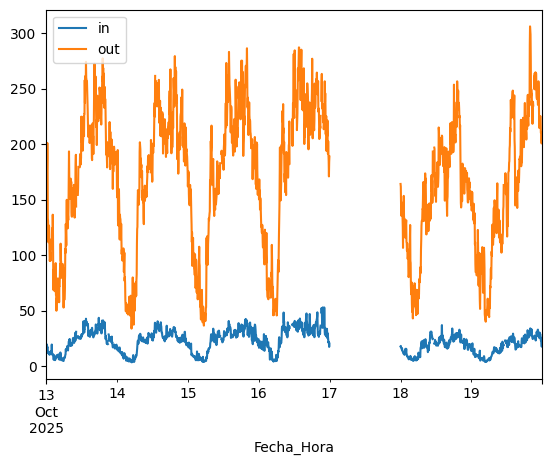

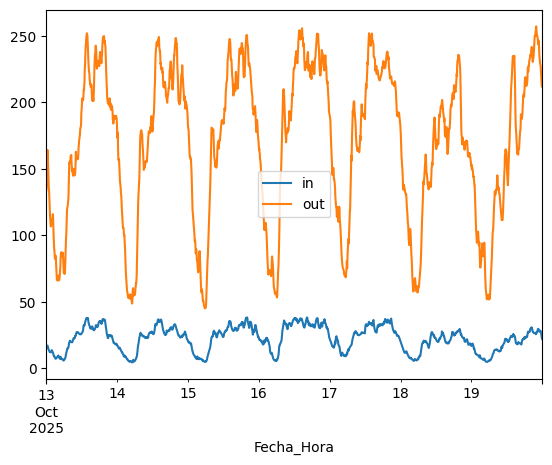

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

def fix_missing_points(series, limit=4):
    return series.interpolate(method='linear', limit=limit, limit_direction='forward')

def fill_nan_with_time_mean(series):

    if not isinstance(series, pd.Series):
        raise TypeError("Input must be a pandas Series.")
        
    filled_series = series.copy()

    if not isinstance(filled_series.index, pd.DatetimeIndex):
        try:
            filled_series.index = pd.to_datetime(filled_series.index)
        except Exception as e:
            raise ValueError("Series index must be convertible to DatetimeIndex.") from e

    time_means = filled_series.groupby([filled_series.index.hour, filled_series.index.minute]).transform('mean')

    filled_series = filled_series.fillna(time_means)

    return filled_series


    _Xs = StandardScaler().fit_transform(data.values.astype(float).reshape(-1, 1))

    _model = KMeans(n_clusters=k, n_init=10, random_state=0).fit(_Xs)
    _centers = _model.cluster_centers_[_model.labels_]
    _distances = np.linalg.norm(_Xs - _centers, axis=1)

    tmp = pd.DataFrame({"c": _model.labels_, "d": _distances}, index=TS_RAND['in'].index)
    
    _stats = tmp.groupby("c")["d"].agg(
        median="median",
        mad=lambda v: np.median(np.abs(v - np.median(v))) + 1e-9
        )
    
    _z = (tmp["d"].to_numpy() - _stats.loc[tmp["c"], "median"].to_numpy()) / _stats.loc[tmp["c"], "mad"].to_numpy()

    _thr = np.quantile(_z[np.isfinite(_z)], pct)
    _is_outlier = _z >= _thr

    return _is_outlier

def replace_outliers_with_nan_kmeans(series, n_clusters=3, contamination=0.05, random_state=42):

    if not isinstance(series, pd.Series):
        raise TypeError("Input must be a pandas Series.")

    valid_data = series.dropna()
    
    if len(valid_data) == 0:
        return series 
        
    X = valid_data.values.reshape(-1, 1)

    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    kmeans.fit(X)

    all_distances = kmeans.transform(X)
    dist_to_center = np.min(all_distances, axis=1)

    threshold = np.quantile(dist_to_center, 1 - contamination)
    outlier_mask_valid = dist_to_center > threshold
    outlier_indices = valid_data.index[outlier_mask_valid]

    series_clean = series.copy()
    
    if not pd.api.types.is_float_dtype(series_clean):
        series_clean = series_clean.astype(float)
        
    series_clean.loc[outlier_indices] = np.nan

    return series_clean


RAW_DATA_IN_OUT = pd.pivot_table(DATA_RAW, values=['in','out'], columns=['Fecha_Hora'], index='Port_Id', aggfunc="sum").stack(level=0, future_stack=True)
RAW_DATA_IN_OUT = RAW_DATA_IN_OUT.T.asfreq('5min').T

EXAMPLE = str(RAW_DATA_IN_OUT.sample().index[0][0])


RAW_DATA_IN_OUT.loc[EXAMPLE].T.plot()

## CLEANING DATA
RAW_DATA_IN_OUT = RAW_DATA_IN_OUT.apply(replace_outliers_with_nan_kmeans, axis=1)
RAW_DATA_IN_OUT = RAW_DATA_IN_OUT.apply(fix_missing_points, axis=1)
RAW_DATA_IN_OUT = RAW_DATA_IN_OUT.apply(fill_nan_with_time_mean, axis=1)
RAW_DATA_IN_OUT = RAW_DATA_IN_OUT.apply(lambda x: x.ewm(alpha=0.2, adjust=False).mean(), axis=1)
RAW_DATA_IN_OUT.loc[EXAMPLE].T.plot()

In [ ]:
RAW_DATA_IN_OUT.groupby(level=0).max().max(axis=1)

Port_Id
0615000139     308.347377
0615000140     307.356174
0615000142     141.075942
0615500139     274.565481
0615500140       0.000000
                 ...     
0826000212    1847.797132
0826000222    1814.163668
0830100007     182.596114
0831100007     251.161369
0831100009     151.401976
Length: 121, dtype: float64

In [ ]:
EDGES_SELECTED

,A,PtaA,Descripcion,B,Type,Capacidad,Instance_Id,Port_Id
995,sara_balneario_m_antof_csr_02134,1/1/6,to_enodeb_02_134_huawei,02_134,SITIO,10001,0831600131,0831600008
1004,sara_anf_av_bllvst_r3_csr_02611,1/1/7,'to_enodeb_02_611_huawei',02_611,SITIO,1001,0831100193,0831100009
1006,sara_anf_av_bllvst_r3_csr_02611,1/1/5,to_mra_antfgst_0/3/2,950d_antofagasta_mr_a_2001,CORE,1001,0831107817,0831100007
1028,sara_3_brigada_acrzda_02521,1/1/5,'to_enodeb_02_521_huawei',02_521,SITIO,1001,0830100186,0830100007
1569,ne8000m14_antofagasta_hr_a_2001,gigabitethernet0/8/4,link_movil_351_to_ne8000-m14_antofagasta_hr_b_...,ne8000m14_antofagasta_hr_b_2001,CORE,10000,0826108260,0826000222
...,...,...,...,...,...,...,...,...
10076,910c_aguas_anf_balm_csr_r5_02413,gigabitethernet0/2/1,to_910c_aguas_anf_boni_csr_r5_02412_0/2/0,910c_aguas_anf_boni_csr_r5_02412,CORE,10000,0615606155,0615500140
10077,910c_aguas_anf_balm_csr_r5_02413,gigabitethernet0/2/0,to_910c_aguas_anf_prat_csr_r5_02404_ge0/2/1,910c_aguas_anf_prat_csr_r5_02404,CORE,10000,0615806155,0615500139
10086,910c_afs_camar_oriente_r6_csr_02605,gigabitethernet0/2/11,'to_enodeb_02_605_huawei',02_605,SITIO,1000,0615000191,0615000142
10087,910c_afs_camar_oriente_r6_csr_02605,gigabitethernet0/2/1,to_910c_molino_fuentes_02046_0/2/1,910c_molino_fuentes_csr_r6_02046,CORE,10000,0704106150,0615000140


In [ ]:
from random import randint

for _ed in G.edges(data=True):
    if randint(0, 10) == 4:
        print(_ed[2])
        display(RAW_DATA_IN_OUT.loc[_ed[2]['port_id']])
    

{'edge_id': '0781907817', 'port_id': '0781700120', 'edge_type': 'CORE'}


Fecha_Hora,2025-10-13 00:00:00,2025-10-13 00:05:00,2025-10-13 00:10:00,2025-10-13 00:15:00,2025-10-13 00:20:00,2025-10-13 00:25:00,2025-10-13 00:30:00,2025-10-13 00:35:00,2025-10-13 00:40:00,2025-10-13 00:45:00,...,2025-10-19 23:10:00,2025-10-19 23:15:00,2025-10-19 23:20:00,2025-10-19 23:25:00,2025-10-19 23:30:00,2025-10-19 23:35:00,2025-10-19 23:40:00,2025-10-19 23:45:00,2025-10-19 23:50:00,2025-10-19 23:55:00
in,0.017292,0.017252,0.017465,0.017445,0.017424,0.017356,0.017560,0.017645,0.017479,0.017534,...,0.017539,0.017535,0.017548,0.017640,0.017583,0.017528,0.017429,0.017368,0.017337,0.017452
out,0.034905,0.034909,0.034696,0.034722,0.034747,0.034752,0.034782,0.034595,0.034684,0.034727,...,0.034622,0.034683,0.034719,0.034502,0.034571,0.034625,0.034698,0.034508,0.034597,0.034661


{'edge_id': '0781906210', 'port_id': '0621000139', 'edge_type': 'CORE'}


Fecha_Hora,2025-10-13 00:00:00,2025-10-13 00:05:00,2025-10-13 00:10:00,2025-10-13 00:15:00,2025-10-13 00:20:00,2025-10-13 00:25:00,2025-10-13 00:30:00,2025-10-13 00:35:00,2025-10-13 00:40:00,2025-10-13 00:45:00,...,2025-10-19 23:10:00,2025-10-19 23:15:00,2025-10-19 23:20:00,2025-10-19 23:25:00,2025-10-19 23:30:00,2025-10-19 23:35:00,2025-10-19 23:40:00,2025-10-19 23:45:00,2025-10-19 23:50:00,2025-10-19 23:55:00
in,11.908461,11.289631,10.842607,11.037018,12.333793,12.569050,12.116052,11.753653,10.600118,10.162859,...,23.737524,23.886541,24.331555,25.439554,25.956353,25.557383,25.170802,24.527089,23.297402,21.701778
out,1.116546,1.086695,1.123457,1.520964,2.106056,2.841215,3.429343,3.881628,4.225240,3.976071,...,2.340263,2.386964,2.405531,2.418684,2.367686,2.311448,2.311845,2.212052,2.100620,2.011474


{'edge_id': '0831107817', 'port_id': '0831100007', 'edge_type': 'CORE'}


...

Fecha_Hora,2025-10-13 00:00:00,2025-10-13 00:05:00,2025-10-13 00:10:00,2025-10-13 00:15:00,2025-10-13 00:20:00,2025-10-13 00:25:00,2025-10-13 00:30:00,2025-10-13 00:35:00,2025-10-13 00:40:00,2025-10-13 00:45:00,...,2025-10-19 23:10:00,2025-10-19 23:15:00,2025-10-19 23:20:00,2025-10-19 23:25:00,2025-10-19 23:30:00,2025-10-19 23:35:00,2025-10-19 23:40:00,2025-10-19 23:45:00,2025-10-19 23:50:00,2025-10-19 23:55:00
in,120.621995,119.888918,120.391578,120.167416,118.033557,116.679477,115.131112,113.892420,112.496596,109.580131,...,117.185916,116.801373,116.599026,115.631881,115.894755,116.076999,114.779272,112.408484,109.545560,105.969543
out,10.516252,10.060503,9.140421,8.216866,7.469503,6.989027,6.604646,6.216705,5.823489,5.529196,...,11.640887,12.522831,12.890233,12.528458,11.564972,10.597270,9.801728,9.190367,8.673941,8.578815


{'edge_id': '0826007889', 'port_id': '0788900122', 'edge_type': 'CORE'}


Fecha_Hora,2025-10-13 00:00:00,2025-10-13 00:05:00,2025-10-13 00:10:00,2025-10-13 00:15:00,2025-10-13 00:20:00,2025-10-13 00:25:00,2025-10-13 00:30:00,2025-10-13 00:35:00,2025-10-13 00:40:00,2025-10-13 00:45:00,...,2025-10-19 23:10:00,2025-10-19 23:15:00,2025-10-19 23:20:00,2025-10-19 23:25:00,2025-10-19 23:30:00,2025-10-19 23:35:00,2025-10-19 23:40:00,2025-10-19 23:45:00,2025-10-19 23:50:00,2025-10-19 23:55:00
in,606.776818,612.822627,614.128760,611.643152,610.715551,603.825138,592.164476,577.165228,563.066472,550.993534,...,721.097974,707.103904,695.573006,683.493979,688.035097,700.036744,690.312979,679.821353,674.720736,663.927670
out,59.007579,58.385150,57.868393,57.329253,57.450974,56.419484,55.371604,54.539454,53.950761,54.983286,...,86.701312,85.375150,84.376093,83.638720,83.786019,85.096660,84.175836,82.927416,82.201653,81.894014


{'edge_id': '0781906738', 'port_id': '0781900139', 'edge_type': 'CORE'}


KeyError: '0781900139'

In [ ]:
def draw_network_with_flows(G, edge_flows, sinks, sources):
    """
    Draws the network graph with edge labels showing the mean flow.
    """
    # Use a fixed layout for reproducibility
    #pos = nx.spring_layout(G, seed=52)

    # Use Kamada-Kawai layout to approximate fixed/equal edge lengths
    # This layout attempts to position nodes so that geometric distance matches graph distance
    try:
        pos = nx.kamada_kawai_layout(G)
    except ImportError:
        # Fallback if scipy is not available (required for kamada_kawai)
        print("Warning: Scipy not found. Using spring_layout as fallback.")
        pos = nx.spring_layout(G, seed=42, k=0.5, iterations=100)

    # Calculate mean flows for labels
    edge_means = {}
    for edge, flow_series in edge_flows.items():
        edge_means[edge] = np.mean(flow_series)

    # Define Node Colors
    node_colors = []
    for node in G.nodes():
        if node in sinks:
            node_colors.append('#ff9999') # Red for Sinks
        elif node in sources:
            node_colors.append('#99ff99') # Green for Sources
        else:
            node_colors.append('#d3d3d3') # Gray for others

    plt.figure(figsize=(10, 6))
    
    # Draw Nodes
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=800, edgecolors='black')
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

    # Draw Edges (Width proportional to mean flow)
    max_flow = max(edge_means.values()) if edge_means else 1.0
    # Base width 1, max width 5
    widths = [1 + 4 * (edge_means.get(e, 0) / max_flow) for e in G.edges()]
    
    nx.draw_networkx_edges(G, pos, width=widths, arrowstyle='-|>', arrowsize=20, edge_color='gray')

    # Draw Edge Labels (Mean Values)
    edge_labels = {e: f"{mean_val:.2f}" for e, mean_val in edge_means.items()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='blue', font_size=9)

    plt.title("Network Topology with Mean Flow per Edge")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
